In [2]:
import sys
from pathlib import Path
from dotenv import load_dotenv

project_root = Path().resolve().parent
sys.path.append(str(project_root))
load_dotenv()

True

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
import pytorch_lightning as pl
from torch.utils.data import Dataset, Subset, DataLoader

from hierroute.constants import *
from hierroute.extra_functions import set_seed
from hierroute.data_setup import ImageDataset, HierImageDataset
from hierroute.hierarchy import Hierarchy
from hierroute import Trainer, HierRouteNet

/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/alexandermichaeltjhin/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
set_seed(SEED)
dataset = ImageDataset(
    data_directory = data_directory,
    data_subdirectories = data_subdirectories,
    class_names = ZOOPLANKTON_CLASSES,
    max_class_size = MAX_CLASS_SIZE,
    image_resolution = RESOLUTION,
    image_transforms = None,
    format_file = '.tif',
    seed = SEED
    )

hier_dataset = HierImageDataset(
    base_dataset=dataset,
    adjacency_graph = hier_adjacency_graph,
    levels=3,
    leaves_only=True
)
hier_dataset.print_dataset_details()

[leaves_only] Kept 48639 samples | Removed 1491 non-leaf samples

Total Dataset: Size = 48639 | Levels = 3
all_node_counts: {0: 48639, 1: 29300, 3: 19728, 12: 6000, 13: 6000, 14: 1728, 15: 6000, 4: 6522, 16: 3023, 17: 3499, 6: 3050, 2: 19339, 7: 4858, 8: 1147, 5: 11288, 11: 5288, 10: 6000, 9: 2046}

nodes_by_level: {0: [0], 1: [1, 2], 2: [3, 4, 6, 7, 8, 5, 9], 3: [12, 13, 14, 15, 16, 17, 11, 10]}


------------------------Level 0------------------------
Level: 0 | Class Name: root                 | Class Label:   0 | Type: Parent | Count:  48639 | Prop: 1.00

------------------------Level 1------------------------
Level: 1 | Class Name: Zoop-yes             | Class Label:   1 | Type: Parent | Count:  29300 | Prop: 0.60
Level: 1 | Class Name: Zoop-No              | Class Label:   2 | Type: Parent | Count:  19339 | Prop: 0.40

------------------------Level 2------------------------
Level: 2 | Class Name: Copepoda             | Class Label:   3 | Type: Parent | Count:  19728 | Prop: 0.41


In [5]:
from torch.utils.data import Dataset, Subset, DataLoader, SequentialSampler, WeightedRandomSampler, random_split
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(180),
    transforms.Pad(padding = 5, fill = 0),
    transforms.Resize((RESOLUTION, RESOLUTION)),
    transforms.ToTensor(),
])


hier_dataset.append_image_transforms(
    image_transforms = train_transforms, replace = True
)

TRAIN_PROP = 0.7
VAL_PROP = 0.1
TEST_PROP = 0.2

BATCH_SIZE = 64

train_split, val_split, test_split = hier_dataset.split_train_test_val(
    train_prop = TRAIN_PROP, val_prop = VAL_PROP, test_prop = TEST_PROP
)

# Create dataloaders
train_loader, val_loader, test_loader = hier_dataset.create_dataloaders(
    batch_size = BATCH_SIZE,
    train_indices = train_split,
    val_indices = val_split,
    test_indices = test_split,
    image_transforms = None,
    train_sample_weights = None,
    balanced=True
)


# Training

In [ ]:
import time
from datetime import date

# 7 epochs took 16 minutes

today = date.today()

if torch.backends.mps.is_available():
    device = torch.device('mps')
    print(f'Using device: MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'Using device: CUDA GPU')
else:
    device = torch.device('cpu')
    print(f'Using device: CPU')
backbone = "swin_t"
# backbone = "efficientnet_b0"
expert_type="cnn"
model = HierRouteNet(hier_dataset.hierarchy, hier_dataset.label_to_ids, 
                #    loss_type = "focal", 
                   backbone= backbone, 
                   freeze_backbone=False,
                   expert_type=expert_type
                   )

HYPERPARAMETERS = {
    # 'optimizer': 'Adam', 
    'lr': 3e-4, 
    'epochs': 40, 
    'scheduler':True,
    'early_stopping': {'patience': 10, 'delta': 0.001},
}

start = time.time()
trainer = Trainer(learning_rate=HYPERPARAMETERS['lr'], max_epochs=HYPERPARAMETERS['epochs'], device=device,
                  print_every=1, model_dir=f"{backbone}_{expert_type}_{today}")
trainer.fit(model, train_loader, val_loader, scheduler=HYPERPARAMETERS['scheduler'],
            patience=HYPERPARAMETERS['early_stopping']['patience'],
            delta=HYPERPARAMETERS['early_stopping']['delta'])
print(f"Total time taken {round((time.time() - start) / 60, 2)} minutes")

Using device: MPS (Apple Silicon GPU)
Total time taken 0.0 minutes


In [9]:
# print(f"loading from {trainer.model_dir}")
saved_dir = "swin_t_cnn_2026-03-31"
model = HierRouteNet(hier_dataset.hierarchy, hier_dataset.label_to_ids, backbone= backbone, checkpoint_dir=saved_dir,
                    expert_type=expert_type)
trainer = Trainer(learning_rate=HYPERPARAMETERS['lr'], max_epochs=HYPERPARAMETERS['epochs'], device=device,
                  print_every=1, model_dir=saved_dir)
result = trainer.predict(model, test_loader, save=True)

Loaded checkpoint: swin_t_cnn_2026-03-31/best_model.pt
Hierarchical Evaluation:
  Level 1: Acc=0.9981 | F1=0.9981 | Prec=0.9980 | Rec=0.9981 | n=9728
    Zoop-yes               Acc=0.9983 | F1=0.9985 | Prec=0.9986 | Rec=0.9983 | n=5860
    Zoop-No                Acc=0.9979 | F1=0.9977 | Prec=0.9974 | Rec=0.9979 | n=3868
  Level 2: Acc=0.9893 | F1=0.9782 | Prec=0.9767 | Rec=0.9797 | n=9728
    Copepoda               Acc=0.9924 | F1=0.9938 | Prec=0.9952 | Rec=0.9924 | n=3945
    Cladocera              Acc=0.9870 | F1=0.9836 | Prec=0.9802 | Rec=0.9870 | n=1305
    Fiber                  Acc=0.9951 | F1=0.9956 | Prec=0.9960 | Rec=0.9951 | n=2258
    Rotifer                Acc=0.9639 | F1=0.9639 | Prec=0.9639 | Rec=0.9639 | n=610
    Bubbles                Acc=0.9990 | F1=0.9990 | Prec=0.9990 | Rec=0.9990 | n=972
    Exoskeleton            Acc=0.9476 | F1=0.9374 | Prec=0.9274 | Rec=0.9476 | n=229
    Plant_Matter           Acc=0.9731 | F1=0.9743 | Prec=0.9755 | Rec=0.9731 | n=409
  Level 3:

# Visualize

Saved → /Users/alexandermichaeltjhin/Everything/Repos/Zooplankton/Zooplankton_Classification/training_result/mnr/swin_t_cnn/train_metrics.png


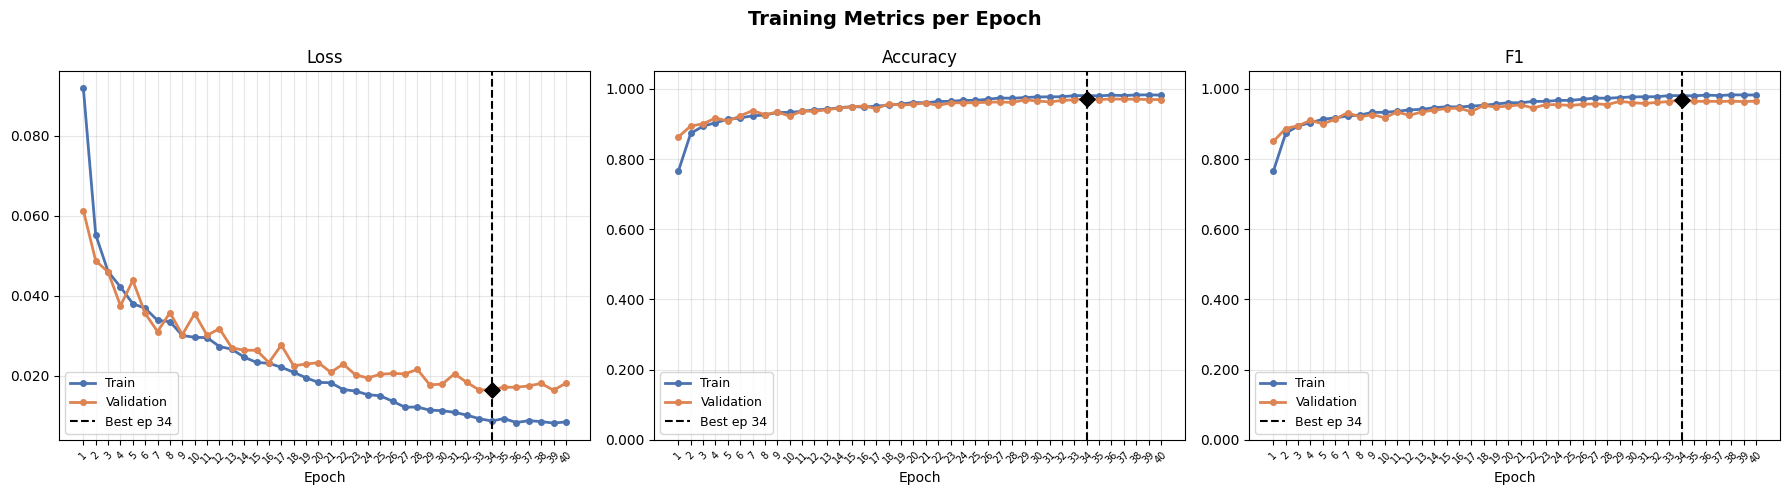

In [9]:
from hierroute import Visualize
# path = trainer.model_dir
path = str(project_root / "training_result/mnr/swin_t_cnn")
vis = Visualize(path)
vis.plot_train()

Saved → training_result/mnr/swin_t_cnn/confusion_matrix_level1.png


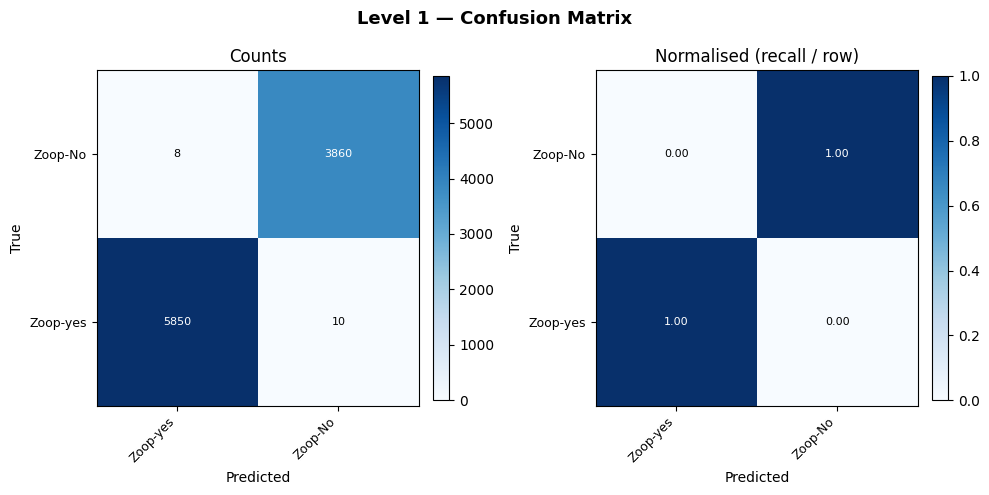

Saved → training_result/mnr/swin_t_cnn/class_metrics_level1.png


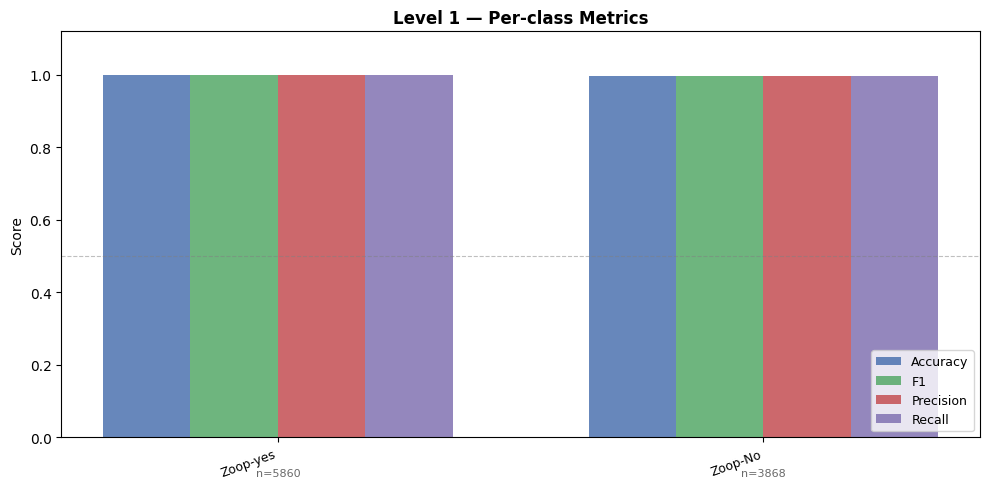

Saved → training_result/mnr/swin_t_cnn/confusion_matrix_level2.png


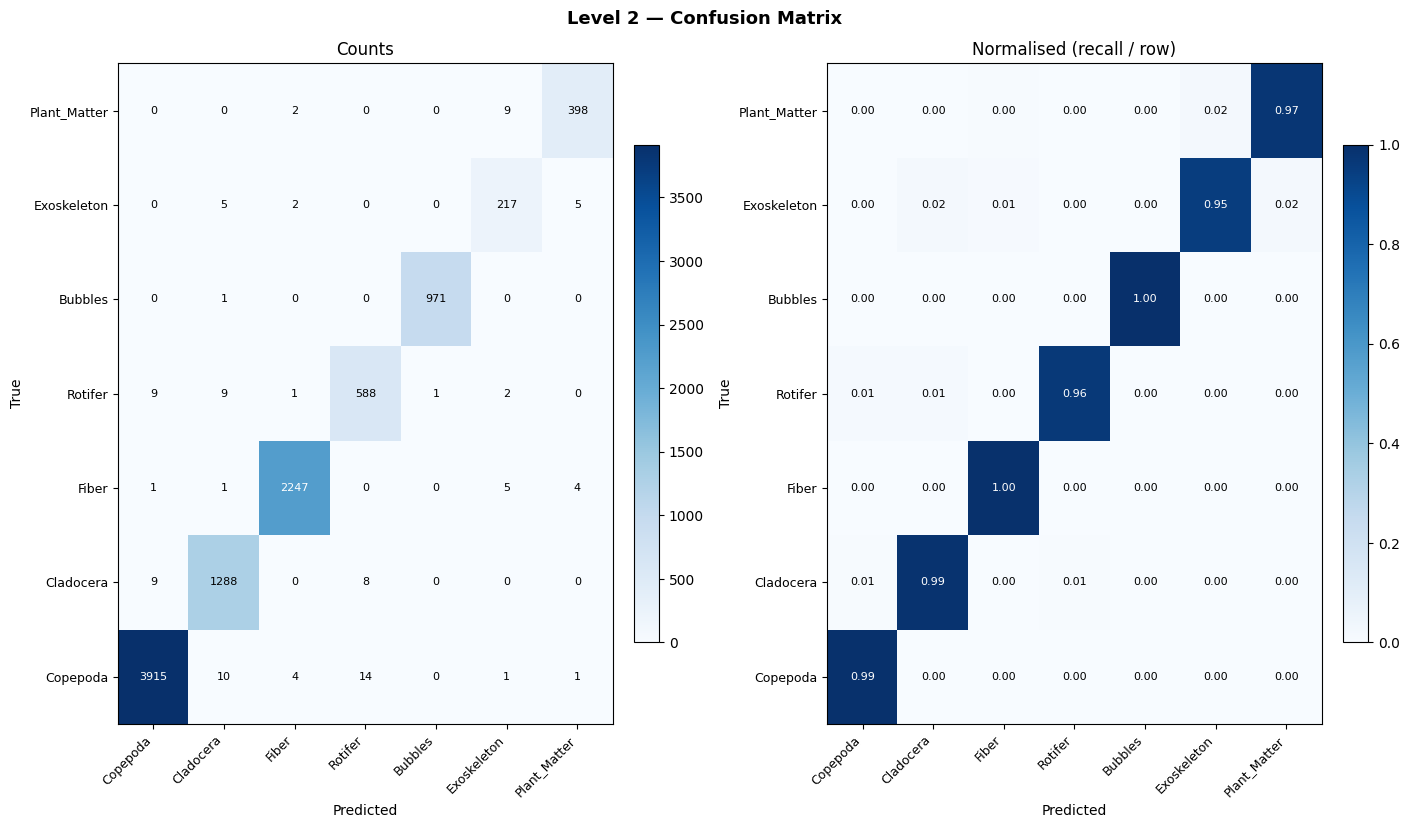

Saved → training_result/mnr/swin_t_cnn/class_metrics_level2.png


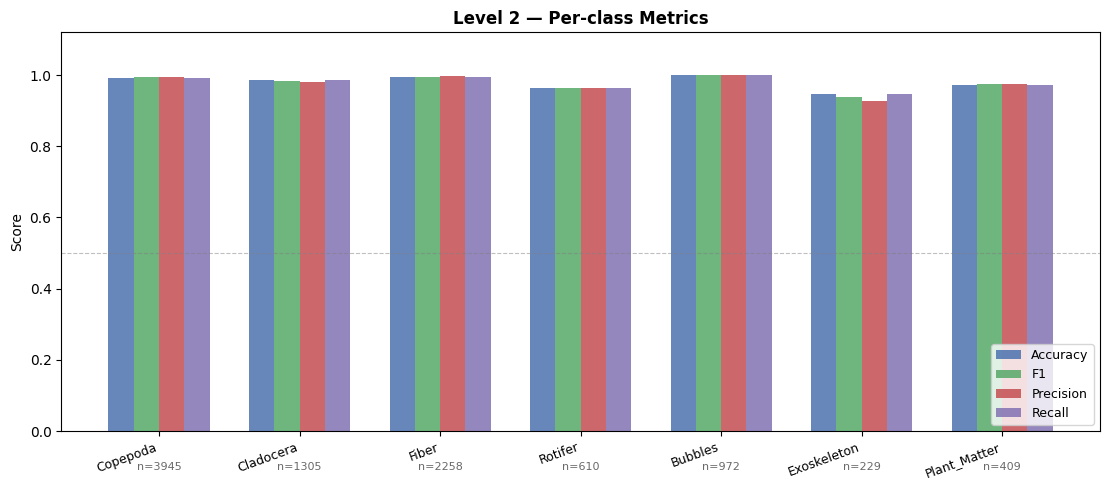

Saved → training_result/mnr/swin_t_cnn/confusion_matrix_level3.png


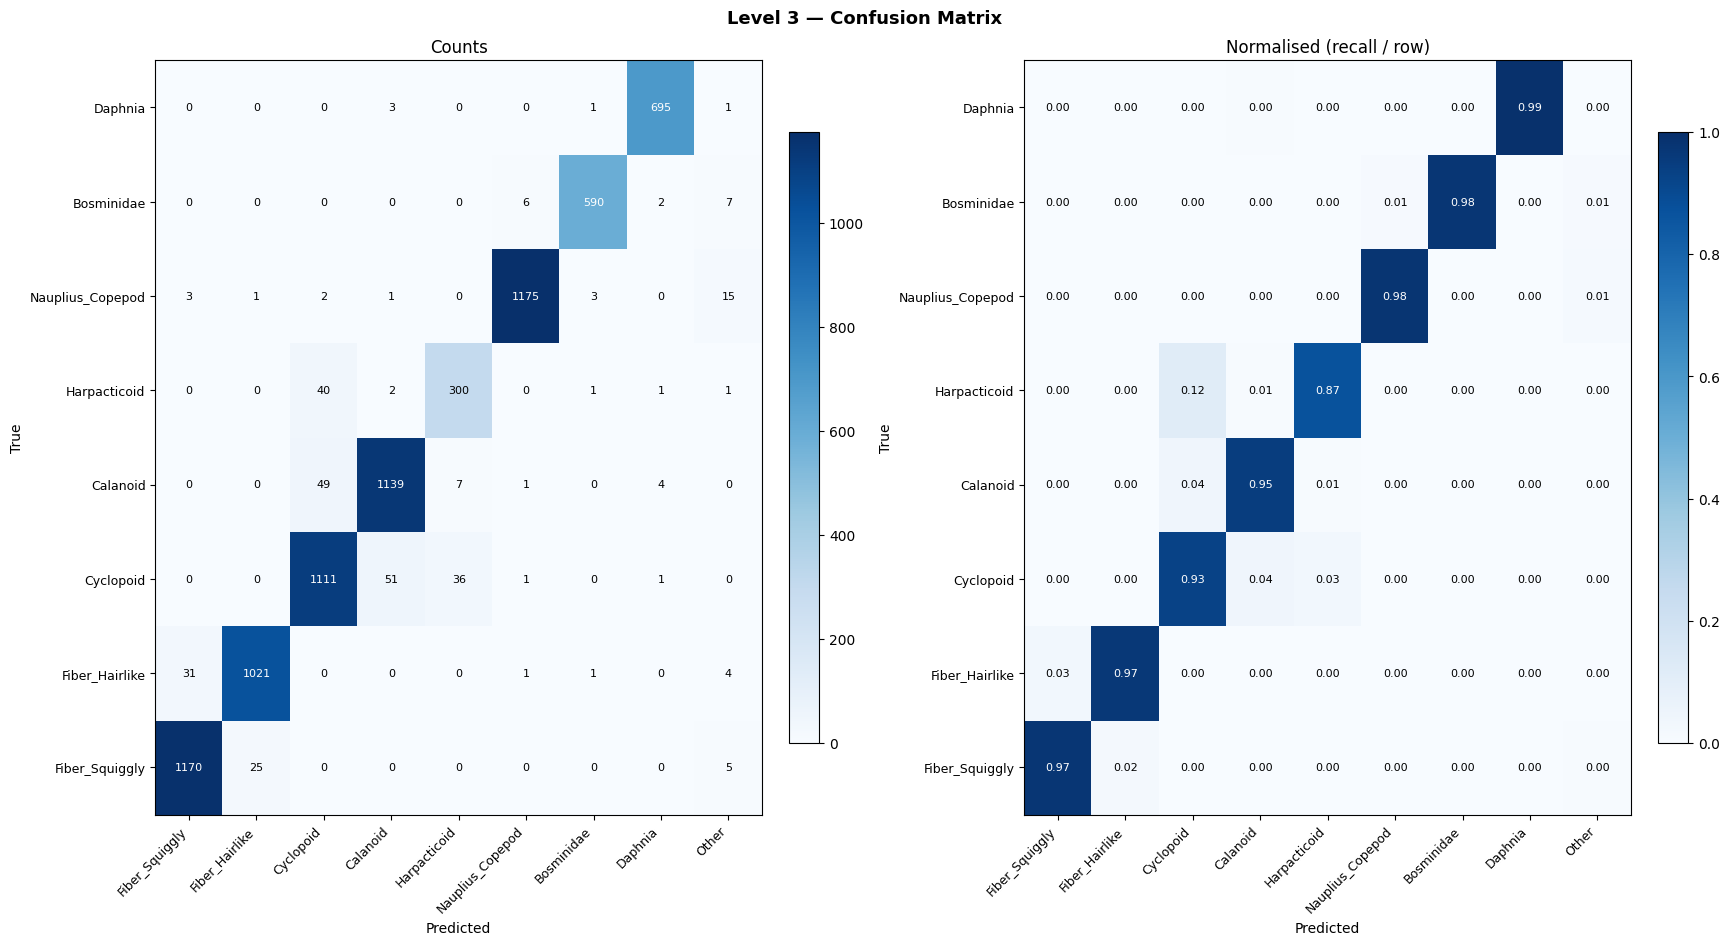

Saved → training_result/mnr/swin_t_cnn/class_metrics_level3.png


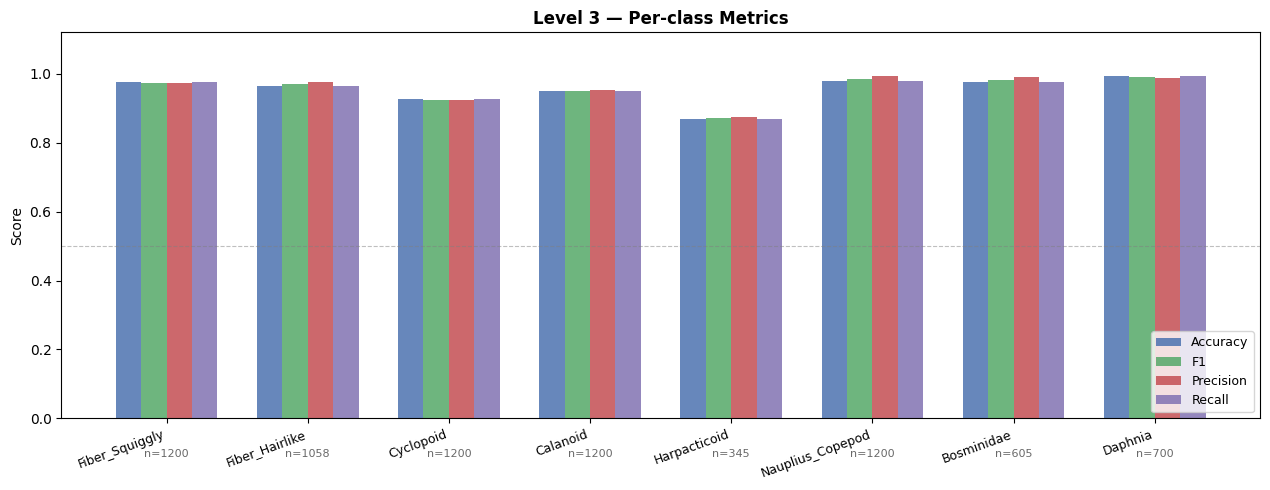

Saved → training_result/mnr/swin_t_cnn/level_comparison.png


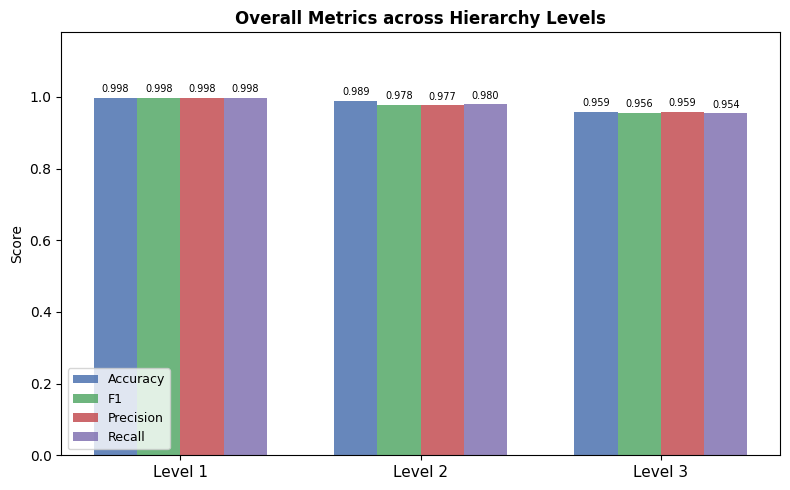

In [10]:
vis.plot_pred()

Saved → training_result/mnr/swin_t_cnn/level_comparison.png


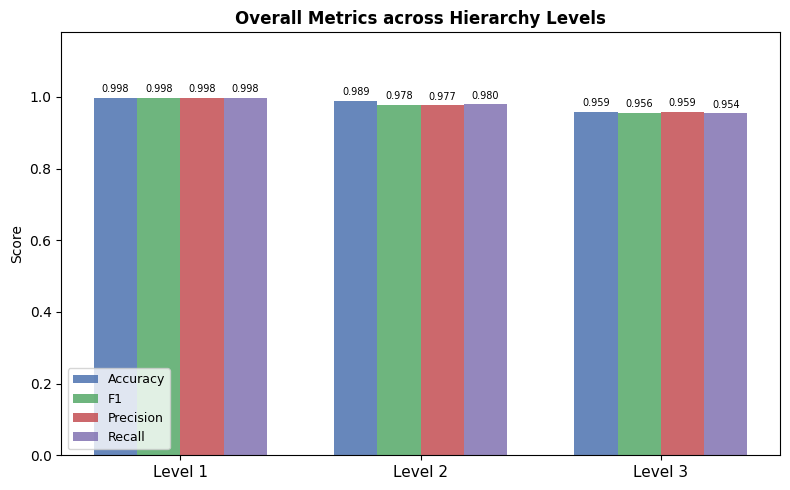

In [11]:
vis.plot_level_comparison()

Saved → training_result/mnr/swin_t_cnn/size_vs_accuracy.png


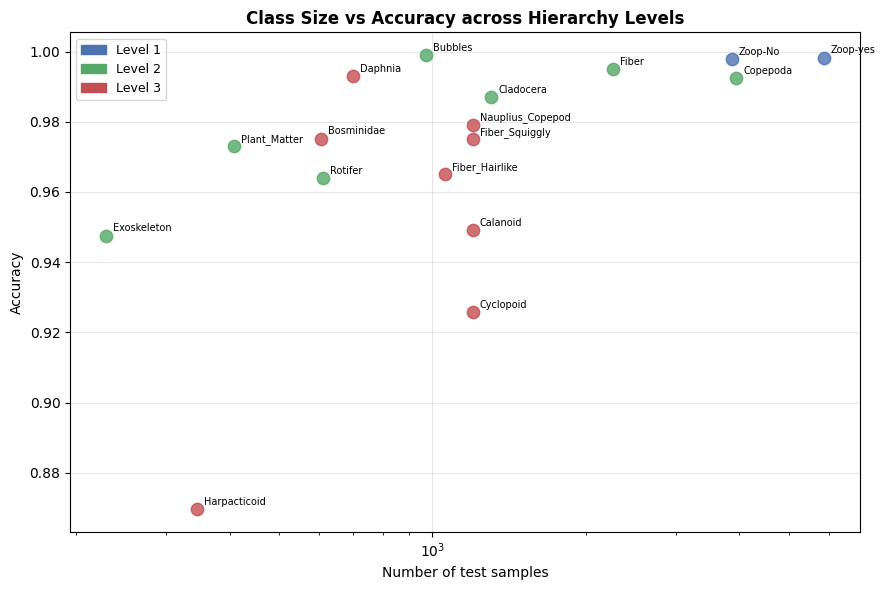

In [12]:
vis.plot_class_size_vs_accuracy()

# Attention

Loaded checkpoint: training_result/mnr/swin_t_cnn/best_model.pt
Saved → training_result/mnr/swin_t_cnn/attention_map.png


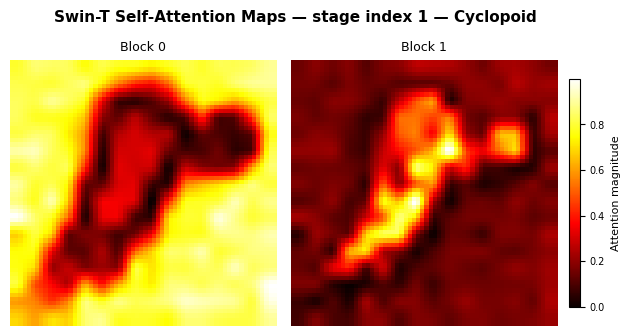

In [5]:
from hierroute import visualize_swin_attention                                                                                                                                                
from torchvision import transforms                                                                                                                                                            
from PIL import Image                                                                                                                                                                         

saved_dir ="training_result/mnr/swin_t_cnn"     
backbone = 'swin_t'
expert_type = "cnn"
model = HierRouteNet(hier_dataset.hierarchy, hier_dataset.label_to_ids, checkpoint_dir=saved_dir,
                   backbone= backbone, expert_type=expert_type)                                                                                                                                                
idx = test_split[155]                                                                                                                                                                           
sample_path = hier_dataset.image_paths[idx]                                                                                                                                                   
                                                                                                                                                                                                
label_id   = hier_dataset.labels[idx]                                                                                                                                                         
label_name = {v: k for k, v in hier_dataset.label_to_ids.items()}[label_id]
img = Image.open(sample_path).convert('L')
img_tensor = transforms.Compose([                                                                                                                                                             
    transforms.Resize((64, 64)),                                                                                                                                                            
    transforms.ToTensor(),                                                                                                                                                                    
])(img).unsqueeze(0).repeat(1, 3, 1, 1)   # (1, 3, 64, 64)                                                                                                                                  
                                                                                                                                                                                            
fig = visualize_swin_attention(model, img_tensor, stage=1,
                                label=label_name,
                                show_input=False,
                                overlay=False,
                                save_path=f"{saved_dir}/attention_map.png")  
                                

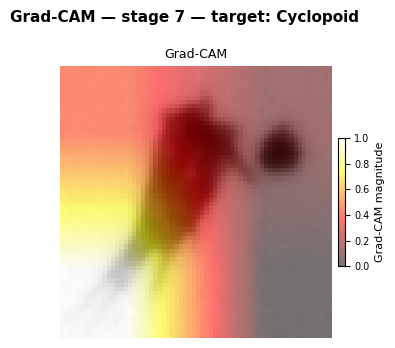

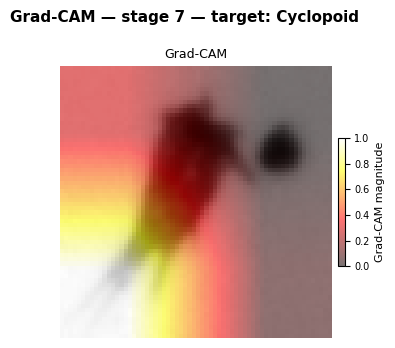

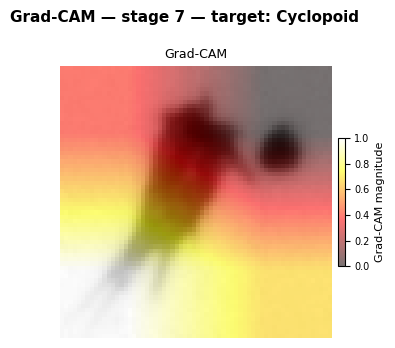

In [25]:
from hierroute.extra_functions import visualize_gradcam
stage=7
# Full hierarchical path                                                                                                                                                     
fig = visualize_gradcam(model, img_tensor, label_name, weights=[1, 0, 0], stage=stage, overlay=True, show_input=False)
                                                                                    
# Species level only (leaf decision only)                                                                                                                                      
fig = visualize_gradcam(model, img_tensor, label_name, weights=[1, 1, 0], stage=stage, overlay=True, show_input=False)
                                                                                    
# Top-level only (zooplankton vs non-zooplankton)                                                                                                                              
fig = visualize_gradcam(model, img_tensor, label_name, weights=[1, 1, 1], stage=stage, overlay=True, show_input=False)